In [ ]:
import ctypes
from picosdk.ps3000a import ps3000a as ps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from picosdk.functions import adc2mV, assert_pico_ok

In [2]:
# Create chandle and status ready for use
status = {}
chandle = ctypes.c_int16()

# Opens the device/s
status["openunit"] = ps.ps3000aOpenUnit(ctypes.byref(chandle), None)

try:
    assert_pico_ok(status["openunit"])
except:

    # powerstate becomes the status number of openunit
    powerstate = status["openunit"]

    # If powerstate is the same as 282 then it will run this if statement
    if powerstate == 282:
        # Changes the power input to "PICO_POWER_SUPPLY_NOT_CONNECTED"
        status["ChangePowerSource"] = ps.ps3000aChangePowerSource(chandle, 282)
        # If the powerstate is the same as 286 then it will run this if statement
    elif powerstate == 286:
        # Changes the power input to "PICO_USB3_0_DEVICE_NON_USB3_0_PORT"
        status["ChangePowerSource"] = ps.ps3000aChangePowerSource(chandle, 286)
    else:
        raise

    assert_pico_ok(status["ChangePowerSource"])

In [3]:
# Set up channel A
# handle = chandle
# channel = PS3000A_CHANNEL_A = 0
enabled = 1
# coupling type = PS3000A_DC = 1
# range = PS3000A_2V = 7 ; PS3000A_10V = 8
channelA_range = ps.PS3000A_RANGE['PS3000A_500MV']
analogue_offset = 0 # 0 V
status["setChA"] = ps.ps3000aSetChannel(chandle,
                                        ps.PS3000A_CHANNEL['PS3000A_CHANNEL_A'],
                                        enabled,
                                        ps.PS3000A_COUPLING['PS3000A_DC'],
                                        channelA_range,
                                        analogue_offset)
assert_pico_ok(status["setChA"])

# Set up channel B
# handle = chandle
# channel = PS3000A_CHANNEL_B = 1
enabled = 1
# coupling type = PS3000A_DC = 1
# range = PS3000A_2V = 7
channelB_range = ps.PS3000A_RANGE['PS3000A_1V']
analogue_offset = 0 # 0 V
status["setChB"] = ps.ps3000aSetChannel(chandle,
                                        ps.PS3000A_CHANNEL['PS3000A_CHANNEL_B'],
                                        enabled,
                                        ps.PS3000A_COUPLING['PS3000A_DC'],
                                        channelB_range,
                                        analogue_offset)
assert_pico_ok(status["setChB"])

# Sets up simple trigger
# Handle = Chandle ; device identifier returned by ps3000aOpenUnit
# Enable = 1 ; zero to disable the trigger; any other value to set the trigger
# Source = ps3000A_channel_A = 0 ; the channel on which to trigger
# Threshold = 1024 ADC counts ; the ADC count at which the trigger will fire
# Direction = ps3000A_Falling = 3 ; the direction in which the signal must move to cause a trigger.
# Direction = ps3000A_Rising = 2 ; The following directions are supported: ABOVE, BELOW, RISING, FALLING and RISING_OR_FALLING.
# Delay = 0 ; the time between the trigger occurring and the first sample.
# autoTrigger_ms = 1000 ; the number of milliseconds the device will wait if no trigger occurs
status["trigger"] = ps.ps3000aSetSimpleTrigger(chandle, 1, ps.PS3000A_CHANNEL['PS3000A_CHANNEL_A'], 0, ps.PS3000A_THRESHOLD_DIRECTION['PS3000A_RISING'], 0, 1000)
assert_pico_ok(status["trigger"])

In [18]:
# Output a sine wave with peak-to-peak voltage of 2 V and frequency of 10 kHz
# handle = chandle
# offsetVoltage = 0
# pkToPk = 2000000
# waveType = ctypes.c_int16(0) = PS3000A_SINE
# startFrequency = 50 Hz
# stopFrequency = 50 Hz
# increment = 0
# dwellTime = 1
# sweepType = ctypes.c_int16(1) = PS3000A_UP
# operation = 0
# shots = 0
# sweeps = 0
# triggerType = ctypes.c_int16(0) = PS3000A_SIGGEN_RISING
# triggerSource = ctypes.c_int16(0) = P3000A_SIGGEN_NONE
# extInThreshold = 1
wavetype = ctypes.c_int16(0)
sweepType = ctypes.c_int32(0)
triggertype = ctypes.c_int32(0)
triggerSource = ctypes.c_int32(0)

status["SetSigGenBuiltIn"] = ps.ps3000aSetSigGenBuiltIn(chandle, 0, 1000000, wavetype, 50, 50, 0, 1, sweepType, 0, 4, 0, triggertype, triggerSource, 1)
assert_pico_ok(status["SetSigGenBuiltIn"])

In [27]:
# Setting the number of sample to be collected
preTriggerSamples = 0
postTriggerSamples = 30000
maxsamples = preTriggerSamples + postTriggerSamples

# Gets timebase infomation
# WARNING: When using this example it may not be possible to access all Timebases as all channels are enabled by default when opening the scope.  
# To access these Timebases, set any unused analogue channels to off.
# Handle = chandle
# Timebase = 2 = timebase
# Nosample = maxsamples
# TimeIntervalNanoseconds = ctypes.byref(timeIntervalns)
# MaxSamples = ctypes.byref(returnedMaxSamples)
# Segement index = 0
timebase = 1252 # 10 ms
timeIntervalns = ctypes.c_float()
returnedMaxSamples = ctypes.c_int16()
status["GetTimebase"] = ps.ps3000aGetTimebase2(chandle, timebase, maxsamples, ctypes.byref(timeIntervalns), 1, ctypes.byref(returnedMaxSamples), 0)
assert_pico_ok(status["GetTimebase"])

# Creates a overlow location for data
overflow = ctypes.c_int16()
# Creates converted types maxsamples
cmaxSamples = ctypes.c_int32(maxsamples)

# Starts the block capture
# Handle = chandle
# Number of prTriggerSamples
# Number of postTriggerSamples
# Timebase = 2 = 4ns (see Programmer's guide for more information on timebases)
# time indisposed ms = None (This is not needed within the example)
# Segment index = 0
# LpRead = None
# pParameter = None
status["runblock"] = ps.ps3000aRunBlock(chandle, preTriggerSamples, postTriggerSamples, timebase, 1, None, 0, None, None)
assert_pico_ok(status["runblock"])

# Create buffers ready for assigning pointers for data collection
# bufferAMax = np.zeros(shape=sizeOfOneBuffer, dtype=np.int16)
# bufferBMax = np.zeros(shape=sizeOfOneBuffer, dtype=np.int16)

# Create buffers ready for assigning pointers for data collection
bufferAMax = (ctypes.c_int16 * maxsamples)()
bufferAMin = (ctypes.c_int16 * maxsamples)() # used for downsampling
bufferBMax = (ctypes.c_int16 * maxsamples)()
bufferBMin = (ctypes.c_int16 * maxsamples)() # used for downsampling

# Setting the data buffer location for data collection from channel A
# Handle = Chandle
# source = ps3000A_channel_A = 0
# Buffer max = ctypes.byref(bufferAMax)
# Buffer min = ctypes.byref(bufferAMin)
# Buffer length = maxsamples
# Segment index = 0
# Ratio mode = ps3000A_Ratio_Mode_None = 0
# status["SetDataBuffers"] = ps.ps3000aSetDataBuffers(chandle, 0, ctypes.byref(bufferAMax), ctypes.byref(bufferAMin), maxsamples, 0, 0)
# assert_pico_ok(status["SetDataBuffers"])

# Set data buffer location for data collection from channel A
# handle = chandle
# source = PS3000A_CHANNEL_A = 0
# pointer to buffer max = ctypes.byref(bufferAMax)
# pointer to buffer min = ctypes.byref(bufferAMin)
# buffer length = maxSamples
# segment index = 0
# ratio mode = PS3000A_RATIO_MODE_NONE = 0
status["setDataBuffersA"] = ps.ps3000aSetDataBuffers(chandle,
                                                     ps.PS3000A_CHANNEL['PS3000A_CHANNEL_A'],
                                                     ctypes.byref(bufferAMax), #bufferAMax.ctypes.data_as(ctypes.POINTER(ctypes.c_int16)),
                                                     None,
                                                     maxsamples,
                                                     0,
                                                     ps.PS3000A_RATIO_MODE['PS3000A_RATIO_MODE_NONE'])
assert_pico_ok(status["setDataBuffersA"])

# Set data buffer location for data collection from channel B
# handle = chandle
# source = PS3000A_CHANNEL_B = 1
# pointer to buffer max = ctypes.byref(bufferBMax)
# pointer to buffer min = ctypes.byref(bufferBMin)
# buffer length = maxSamples
# segment index = 0
# ratio mode = PS3000A_RATIO_MODE_NONE = 0
status["setDataBuffersB"] = ps.ps3000aSetDataBuffers(chandle,
                                                     ps.PS3000A_CHANNEL['PS3000A_CHANNEL_B'],
                                                     ctypes.byref(bufferBMax), #bufferBMax.ctypes.data_as(ctypes.POINTER(ctypes.c_int16)),
                                                     None,
                                                     maxsamples,
                                                     0,
                                                     ps.PS3000A_RATIO_MODE['PS3000A_RATIO_MODE_NONE'])

# Creates a overlow location for data
overflow = (ctypes.c_int16 * 10)()
# Creates converted types maxsamples
cmaxSamples = ctypes.c_int32(maxsamples)

# Checks data collection to finish the capture
ready = ctypes.c_int16(0)
check = ctypes.c_int16(0)
while ready.value == check.value:
    status["isReady"] = ps.ps3000aIsReady(chandle, ctypes.byref(ready))

# Handle = chandle
# start index = 0
# noOfSamples = ctypes.byref(cmaxSamples)
# DownSampleRatio = 0
# DownSampleRatioMode = 0
# SegmentIndex = 0
# Overflow = ctypes.byref(overflow)

status["GetValues"] = ps.ps3000aGetValues(chandle, 0, ctypes.byref(cmaxSamples), 0, 0, 0, ctypes.byref(overflow))
assert_pico_ok(status["GetValues"])

# Finds the max ADC count
# Handle = chandle
# Value = ctype.byref(maxADC)
maxADC = ctypes.c_int16()
status["maximumValue"] = ps.ps3000aMaximumValue(chandle, ctypes.byref(maxADC))
assert_pico_ok(status["maximumValue"])

# Converts ADC from channel A to mV
adc2mVChAMax = adc2mV(bufferAMax, channelA_range, maxADC)
adc2mVChBMax = adc2mV(bufferBMax, channelB_range, maxADC)

# Creates the time data
time_axis = np.linspace(0, (cmaxSamples.value - 1) * timeIntervalns.value, cmaxSamples.value)

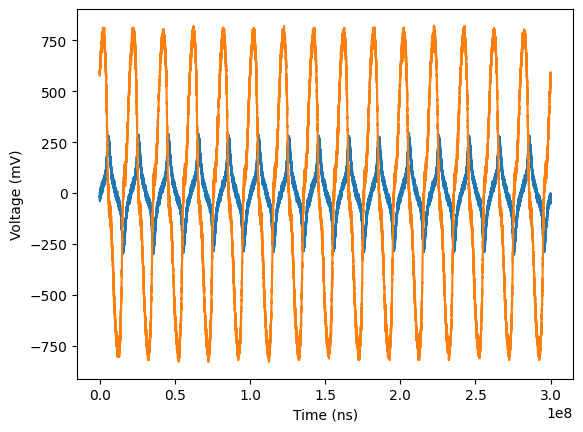

In [28]:
# Plots the data from channel A onto a graph
plt.plot(time_axis, adc2mVChAMax[:])
plt.plot(time_axis, adc2mVChBMax[:])
plt.xlabel('Time (ns)')
plt.ylabel('Voltage (mV)')
plt.show()

In [ ]:
df = pd.DataFrame({'time' : time_axis, 'ch_A' : adc2mVChAMax, 'ch_B' : adc2mVChBMax})

In [30]:
df.head(30)

,time,ch_A,ch_B
0,0.0,0.000000,594.211368
1,10000.0,-13.210507,602.977362
2,20000.0,-13.210507,594.211368
3,30000.0,0.000000,576.740896
4,40000.0,-13.210507,594.211368
5,50000.0,-8.812131,585.476132
6,60000.0,-22.038017,594.211368
7,70000.0,-13.210507,594.211368
8,80000.0,-17.624262,585.476132
9,90000.0,-17.624262,594.211368


In [31]:
filename = time.strftime("%Y-%m-%d_%H-%M")
df.to_csv(f"rawdata_{filename}.csv")


In [32]:
# Stops the scope
# Handle = chandle
status["stop"] = ps.ps3000aStop(chandle)
assert_pico_ok(status["stop"])

# Closes the unit
# Handle = chandle
status["close"] = ps.ps3000aCloseUnit(chandle)
assert_pico_ok(status["close"])

# Displays the staus returns
print(status)

{'openunit': 0, 'setChA': 0, 'setChB': 0, 'trigger': 0, 'SetSigGenBuiltIn': 0, 'GetTimebase': 0, 'runblock': 0, 'setDataBuffersA': 0, 'setDataBuffersB': 0, 'isReady': 0, 'GetValues': 0, 'maximumValue': 0, 'stop': 0, 'close': 0}
